# 01 — Problem Definition and Experimental Design

**Maps to:** `report/Chapters/Task1.tex` (label `Task1`).  
**Tickets:** TICKET-01 (benchmark choice), TICKET-02 (formal formulation), TICKET-04 (loader + distance matrix).

Code that backs this notebook lives in `src/ga/instance.py`.

## 1.1 Benchmark TSP Instance — TICKET-01
Maps to `T1:Benchmark`.

Document: name, dimension, edge-weight type, known optimal tour length, source citation. Justify the choice (size ≥70 ≤150, instance class).

Candidates: `eil101`, `kroA100`, `ch150`, `lin105`. Final pick → write into `Task1.tex` §`T1:Benchmark` and into the README dataset entry.

### Compare Four Datasets

Datasets of these `.tsp` files are from:

https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp.html

In the task here, four datasets files that contains 70-150 cities will be compared.

The datasets file consist of `ch150.tsp`, `eil101.tsp`, `kroA100.tsp`, and `lin105.tsp`.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import tsplib95

Matplotlib is building the font cache; this may take a moment.


Below path is to retrieved file format for `.tsp`:

In [2]:
DATA_PATH = Path("../data/TSP-dataset")

datasets = ["ch150", "eil101", "kroA100", "lin105"]


# To load and store coordinates from the files
def load_tsp(name):
    path = DATA_PATH / f"{name}.tsp"
    problem = tsplib95.load(str(path))
    coords = dict(problem.node_coords)
    return coords

#### City Count

In this section, based on the bar chart below, we can see that these datasets contains cities that fulfil the required range of 70 - 150 cities, which confirms that the selected datasets are suitable for this task.

In [3]:
loaded = {}
for name in datasets:
    loaded[name] = load_tsp(name)
    print(f"{name}: {len(loaded[name])} cities count")

ch150: 150 cities count
eil101: 101 cities count
kroA100: 100 cities count
lin105: 105 cities count


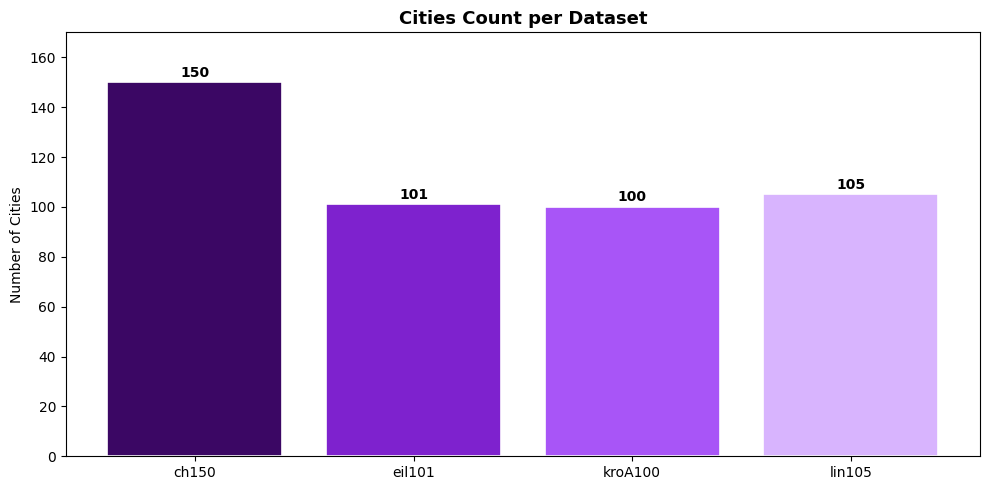

In [4]:
city_counts = {name: len(loaded[name]) for name in datasets}

colors = {
    "ch150": "#3B0764",  # deep violet
    "eil101": "#7E22CE",  # purple
    "kroA100": "#A855F7",  # medium purple
    "lin105": "#D8B4FE",  # lavender
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(city_counts.keys())
counts = list(city_counts.values())
bars = ax.bar(
    names, counts, color=[colors[n] for n in names], edgecolor="white", linewidth=1.2
)

ax.set_title("Cities Count per Dataset", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Cities", fontsize=10)
ax.set_ylim(0, max(counts) + 20)

# ax.axhline(y=70,  color='red',  linestyle='--', linewidth=1, alpha=0.6, label='Min required (70)')
# ax.axhline(y=150, color='blue', linestyle='--', linewidth=1, alpha=0.6, label='Max required (150)')
# ax.legend(fontsize=9)

for bar, val in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(val),
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()

# To save the picture, but no need
# plt.savefig(DATA_PATH + 'citycount.png',
#            dpi=150, bbox_inches='tight')

plt.show()

From the bar chart above, the **ch150** dataset has 150 cities, the **eil101** dataset has 101 cities, the **kroA100** dataset has 100 cities, and the **lin105** dataset has 105 cities.

Actually, from the dataset file name itself, we can know how many cities there.

#### Coordinate Format

The coordinate format section determines on how distances between cities are calculated. All of these four datasets use **EUC_2D** format. This format means that the distances are computed using the standard two-dimensional Euclidean formula.

In [5]:
def get_coord_format(name):
    # use the .tsp file path
    path = DATA_PATH / f"{name}.tsp"
    with open(path) as f:
        for line in f:
            # search for a line contains EDGE_WEIGHT_TYPE
            if "EDGE_WEIGHT_TYPE" in line:
                # take the part after string was cut at :
                # because in the file it look like this: EDGE_WEIGHT_TYPE: EUC_2D
                # [0] is EDGE_WEIGHT_TYPE, [1] is EUC_2D
                # .strip() function as to delete space at the front and the back (if there any)
                return line.split(":")[1].strip()
    return "Unknown"


# retrieve the format of all dataset
coord_formats = {name: get_coord_format(name) for name in datasets}

for name, fmt in coord_formats.items():
    print(f"  {name:10s} : {fmt}")

  ch150      : EUC_2D
  eil101     : EUC_2D
  kroA100    : EUC_2D
  lin105     : EUC_2D


Based on the block of codes above, all of the four datasets utilise the same **EUC_2D** distance format.

But these coordinate format doesn't serve as a differentiating factor in the dataset selection since all four datasets are equally compatible with GA implementation. It is because the EUC_2D format is straightforwad to compute and widely supported in TSP task.

#### Known Optimal Tour Length

Datasets for `.opt.tour` files also from:

https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp.html

The `.opt.tour` file contains the **sequence of cities**
that form the optimal tour (shortest path) that has
been proven by TSPLIB95.

Below path is to retrieved file format for  `opt.tour`:

In [6]:
DATA_PATH_1 = Path("../data/TSP-datasets-opt-tour")

datasets_2 = ["ch150", "eil101", "kroA100", "lin105"]

In [7]:
# read_opt_tour(): reads file line by line
# and extracts the city sequence
def read_opt_tour(name):
    path = DATA_PATH_1 / f"{name}.opt.tour"
    tour = []
    with open(path) as f:
        reading = False
        for line in f:
            line = line.strip()
            if line == "TOUR_SECTION":
                reading = True
                continue
            if line == "-1" or line == "EOF":
                break
            if reading:
                # handle numbers on single or multiple lines
                for token in line.split():
                    if token.lstrip("-").isdigit():
                        city = int(token)
                        if city != -1:
                            tour.append(city)
    return tour

The optimal tour length is calculate by adding the Euclidean 2D distances between cities and should be in the optimal tour sequences.

Euclidean 2D Formula:
$$d(i, j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

where:

- $d(i, j)$ = distance between city  $i$ and city $j$
- $x_i, y_i$ = city $i$ coordinate
- $x_j, y_j$ = city $j$ coordinate

Calculating Tour Length's Total Formula:

$$\text{Tour Length} = \sum_{i=1}^{n} d(\text{tour}[i],\ \text{tour}[(i+1)\ \%\ n])$$

Where:
- $\sum_{i=1}^{n}$ = sum all distances from city 1 to city $n$
- $d(\cdot, \cdot)$ = EUC\_2D distance between two cities
- $\text{tour}[i]$ = current city being visited
- $\text{tour}[(i+1)\ \%\ n]$ = next city to visit
- $\%\ n$ = modulo operator — ensures the last city
  returns back to the first city, completing the closed tour
- $n$ = total number of cities in the tour


In [8]:
# calculate distance between two cities
def euclidean(c1, c2):
    # original formula giving result as a floating point, not rounded,
    # so the optimal tour length might differ than what was stated inside file
    # return math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

    # by adding 0.5, it will be rounded properly
    return int(math.sqrt((c1[0] - c2[0]) ** 2 + (c1[1] - c2[1]) ** 2) + 0.5)


def calc_tour_length(tour, coords):
    total = 0
    n = len(tour)
    for i in range(n):
        c1 = coords[tour[i]]
        c2 = coords[tour[(i + 1) % n]]
        total += euclidean(c1, c2)
    return round(total)


opt_tours = {}
opt_lengths = {}

print("Known Optimal Tour Length:")

for name in datasets_2:
    opt_tours[name] = read_opt_tour(name)
    opt_lengths[name] = calc_tour_length(opt_tours[name], loaded[name])
    print(f"{name} = {opt_lengths[name]:,}")

Known Optimal Tour Length:
ch150 = 6,528
eil101 = 629
kroA100 = 21,282
lin105 = 14,379


Based on the counting we received shown above, **eil101** has the smallest optimal tour length (629), which tell us that the cities are very close to each other (highly packed). This can cause the Genetic Algorithm (GA) reach the solution much faster and reducing the difficulty and of the search space, providing little insight into its true performance.

Next, **lin105** has an optimal tour length of 14,379 and **ch150** has an optimal tour length of 6,528. Do note that the **ch150** has a smaller optimal value despite having more cities, which means it cities are more closely packed. And that will make the GA can locate the good solutions much easier since highly packed cities reduces the search space complexity.

Lastly, **kroA100** recorded a moderate optimal tour length of 21,282, which is telling us that its cities are well-distributed
across the search space. This balanced distribution makes it neither too easy nor too difficult for the GA, providing a fair environment to observe the algorithm's true search behaviour.


#### Source Citation

All of these four datasets were obtained from **TSPLIBS95**, where it was introduced by Reinelt (1991) as a standardized benchmark library for the Travelling Salesman Problem (TSP).

In [13]:
citations = {
    "ch150": "Churritz",
    "eil101": "Christofides & Eilon",
    "kroA100": "Krolak, Felts & Nelson",
    "lin105": "Lin",
}

print("=" * 60)
print(f"  {'Dataset(s)':15s} {'Author':27s} {'Cities'}")
print("-" * 60)
for name in datasets_2:
    print(f"  {name:15s} {citations[name]:27s} {len(loaded[name])}")
print("=" * 60)
print("Source : TSPLIB95")
print("Reinelt, G. (1991). TSPLIB — A Traveling Salesman")
print("Problem Library. ORSA Journal on Computing")
# print("3(4), 376-384.")

  Dataset(s)      Author                      Cities
------------------------------------------------------------
  ch150           Churritz                    150
  eil101          Christofides & Eilon        101
  kroA100         Krolak, Felts & Nelson      100
  lin105          Lin                         105
Source : TSPLIB95
Reinelt, G. (1991). TSPLIB — A Traveling Salesman
Problem Library. ORSA Journal on Computing


### Selected Instance

Selected instance is: **kroA100**

| Property | Details |
|---|---|
| Name | kroA100 |
| Dimension (City Count) | 100 cities |
| Edge-Weight Type | EUC_2D |
| Known Optimal Tour Length | 21,282 |
| Source | Reinelt, G. (1991). TSPLIB - A Traveling Salesman Problem Library. ORSA Journal on Computing |

kroA100 is selected as the benchmark instance for this study based on four criteria, such as the city's count, known optimal tour length, coordinate format, and source citation. It is because for the city's count, kroA100 dataset contains 100 cities, so it matches within the needed range of 70-150 cities and providing enough amount of complexity to demonstrate the behavior of the Genetic Algorithm while avoiding being too computationally challenging. Plus, despite having 100 cities count, kroA100 has the best tour duration of 21,282, that indicates a well-distributed city layout, providing a balanced challenges for the GA to optimize without being too easy or difficult. kroA100 is also widely referenced in GA and metaheuristic literature (Reinelt, 1991), allowing for direct comparison with existing studies. Lastly, the EUC_2D coordinate format is used similarly in all all four candidate datasets to ensure fair and unbiased selection.

In [10]:
# TICKET-04 — exercise src/ga/instance.py here.
# from ga.instance import load_tsp
# coords, dist_matrix = load_tsp('../data/<chosen>.tsp')
# print(coords.shape, dist_matrix.shape)

In [14]:
# Scatter of cities — sanity check the loader. Save figure to results/figures/ for Task1.

## 1.2 Formal Mathematical Formulation — TICKET-02
Maps to `T1:Formulation`.

Pure-prose ticket. Draft the formulation here as Markdown / LaTeX-in-Markdown, then promote into `Task1.tex` §`T1:Formulation`:
- decision variables $x_{ij} \in \{0,1\}$;
- objective: minimise $\sum_{i,j} d_{ij} x_{ij}$;
- constraints (visit-once, closed tour, sub-tour elimination);
- properties relevant to evolutionary optimisation.

```
The Traveling Salesman Problem (TSP) is a combinatorial optimization problem where the objective is to find the shortest possible route that visits every city exactly once and returns to the starting city.

In this project, the selected benchmark instance is **kroA100** from TSPLIB95. This instance contains **100 cities**, where each city is represented by two-dimensional coordinates. The distance between cities is calculated using the **EUC_2D** Euclidean distance metric.

The TSP can be represented as a complete weighted graph:
```


The TSP can be represented as a complete weighted graph:

$$
G = (V, E)
$$

where:

- $V = \{1,2,\ldots,n\}$ is the set of cities
- $E$ is the set of edges connecting the cities
- $n = 100$ for the kroA100 instance
- $d_{ij}$ represents the distance between city $i$ and city $j$

### Decision Variables



The decision variable is defined as:

$$
x_{ij} =
\begin{cases}
1, & \text{if the tour travels directly from city } i \text{ to city } j \\
0, & \text{otherwise}
\end{cases}
$$

where:

$$
i,j \in V, \quad i \neq j
$$

This means that $x_{ij}$ shows whether the path from city $i$ to city $j$ is selected in the final tour.

Where $i,j \in V$ means that both cities $i$ and $j$ belong to the set of cities, and $i \neq j$ means that the tour cannot travel from a city back to the same city directly.

### Objective Function


The objective of the TSP is to minimize the total distance travelled by the salesman.

$$
\min Z = \sum_{i=1}^{n} \sum_{\substack{j=1 \\ j \neq i}}^{n} d_{ij}x_{ij}
$$

where:

- $Z$ is the total tour distance
- $d_{ij}$ is the distance from city $i$ to city $j$
- $x_{ij}$ indicates whether the edge from city $i$ to city $j$ is selected
- $n = 100$ for the kroA100 instance

The goal is to find the tour with the smallest possible value of $Z$.

### Constraints

#### 1. Each city must be entered exactly once

$$
\sum_{\substack{i=1 \\ i \neq j}}^{n} x_{ij} = 1,
\quad \forall j \in V
$$

This constraint ensures that every city has exactly one incoming route.

#### 2. Each city must be left exactly once

$$
\sum_{\substack{j=1 \\ j \neq i}}^{n} x_{ij} = 1,
\quad \forall i \in V
$$

This constraint ensures that every city has exactly one outgoing route. In other words, after visiting a city, the tour must leave that city and continue to exactly one other city.

#### 3. The tour must return to the starting city

The TSP requires a closed tour. This means the salesman must return to the starting city after visiting all other cities.

This condition is achieved when the incoming and outgoing constraints are combined with the subtour elimination constraint, ensuring that all cities form one complete closed tour.


#### 4. Subtour Elimination Constraint

The previous constraints may still produce smaller disconnected cycles known as subtours. Therefore, subtour elimination constraints are needed:

$$
\sum_{i \in S} \sum_{\substack{j \in S \\ j \neq i}} x_{ij} \leq |S| - 1,
\quad \forall S \subset V, \quad 2 \leq |S| \leq n-1
$$

This constraint prevents the formation of smaller cycles that do not include all cities.

This constraint makes sure that the solution forms one complete tour visiting all cities, instead of forming two or more small separate loops.

#### 5. Binary Constraint

$$
x_{ij} \in \{0,1\},
\quad \forall i,j \in V, \quad i \neq j
$$

This means that each edge is either selected or not selected.

If $x_{ij} = 1$, the path from city $i$ to city $j$ is included in the tour.

If $x_{ij} = 0$, the path from city $i$ to city $j$ is not included in the tour.

The value of xij can only be 0 or 1. It cannot be 0.5, 2, or any other value.

### Properties Relevant to Evolutionary Optimization

The TSP is suitable for Genetic Algorithm optimization because it has a very large search space. A solution to the TSP can be represented as a permutation of cities.

For $n$ cities, the number of possible unique tours is:

$$
\frac{(n-1)!}{2}
$$

```
For the kroA100 instance with 100 cities, the number of possible tours is extremely large. Because of this, checking every possible solution using exhaustive search is not practical.
```

In a Genetic Algorithm, each chromosome represents one possible TSP tour. For example, a chromosome may be written as:

$$
[1, 5, 12, 8, 20, \ldots, 100]
$$

This represents the visiting order of the cities. The return to the starting city is assumed when calculating the total tour distance.

```
This represents the order in which the cities are visited. A valid chromosome must include each city exactly once before returning to the starting city.

However, some genetic operators, especially naive crossover or mutation operators, may produce infeasible chromosomes with repeated or missing cities. Therefore, repair mechanisms are needed when feasibility is not preserved automatically.

The kroA100 instance is also useful for Genetic Algorithm analysis because it uses Euclidean distance. This means nearby cities may form useful partial routes, also known as building blocks. These building blocks can be preserved and combined through crossover and mutation to produce better solutions over generations.

Overall, the TSP is appropriate for evolutionary optimization because it has a large search space, permutation-based solutions, and strong dependency between the order of cities and the final tour distance.
```

## 1.3 Experimental-Setup Justification — feeds TICKET-15/16
Maps to `T1:Setup`.

Decide and justify:
- number of independent runs (target ≥30);
- termination (max generations / convergence threshold);
- parameter ranges for the sweep (population size, crossover rate, mutation rate, selection method).

These decisions become the default config dict consumed by `experiments/run.py` and `experiments/sweep.py`.